In [ ]:
import sys
import muon as mu 

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')

from Interpretation.Plotting.src import merge_pdfs_in_folder, merge_svgs_to_pdf

from Interpretation.Plotting.src import plot_umap_per_program, plot_top_gene_per_program, top_GO_per_program, compute_program_correlation_matrix,\
                              analyze_program_correlations, plot_violin, plot_program_log2FC, plot_program_heatmap, plot_program_volcano, \
                              perturbed_program_dotplot, compute_program_waterfall_cor, create_program_correlation_waterfall, create_comprehensive_program_plot

# Find programs & formatting check

In [ ]:
#IO path
save_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/020326_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Plot/Program"

# data path  
mdata_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/020326_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/adata/cNMF_50_0_2.h5mu"


# resourse path
perturb_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/020326_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Evaluation/50_0_2/50_CRT_d0.txt"
perturb_path_base = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/020326_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Evaluation/50_0_2/50_CRT"
file_to_dictionary = None
reference_gtf_path=None
GO_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/020326_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Evaluation/50_0_2/50_GO_term_enrichment.txt"

# precomputed waterfall correlation matrix base path (set to None to compute from scratch)
corr_matrix_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/020326_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Evaluation/50_0_2"

# keys 
top_program = 5
prog_key = 'cNMF'
data_key = 'rna'
categorical_key = 'timepoint'
sample = ['d0', 'd1', 'd2', 'd3']
log2fc_col = 'log2FC'

# UMAP subsampling (set to None to plot all cells, or e.g. 0.1 for 10%)
subsample_frac = 0.1

In [ ]:
# read data
mdata = mu.read_h5mu(mdata_path)

In [ ]:
# reformate if needed 
def _assign_guide(mdata, mdata_guide):
        mdata['cNMF'].uns['guide_names'] = mdata_guide['rna'].uns['guide_names']
        mdata['cNMF'].uns['guide_targets'] = mdata_guide['rna'].uns['guide_targets']
        mdata['cNMF'].obsm['guide_assignment'] = mdata_guide['rna'].obsm['guide_assignment'].toarray()
        mdata['cNMF'].obsm['X_pca'] = mdata_guide['rna'].obsm['X_pca'] 
        mdata['cNMF'].obsm['X_umap'] = mdata_guide['rna'].obsm['X_umap'] 

#mdata_guide = mu.read(mdata_guide_path)
_assign_guide(mdata, mdata)

In [7]:
# check umap exist 
if 'X_umap' not in mdata['cNMF'].obsm:
    
    import scanpy as sc
    sc.tl.pca(mdata['rna'], n_comps=50)
    sc.pp.neighbors(mdata['rna'])
    sc.tl.umap(mdata['rna'])
    mdata['cNMF'].obsm['X_pca'] = mdata['rna'].obsm['X_pca'] 
    mdata['cNMF'].obsm['X_umap'] = mdata['rna'].obsm['X_umap'] 

In [ ]:
# get program list
program_len = len(mdata['cNMF'].var)
len(mdata['cNMF'].var)

50

In [ ]:
import numpy as np

# found detected perturbed gene
perturbed_gene = np.unique(mdata['cNMF'].uns["guide_targets"])
gene_list = mdata['rna'].var_names.tolist()
perturbed_gene_found = list(set(gene_list) & set(perturbed_gene.tolist()))

# sort list by alphabetical order 
perturbed_gene_found = sorted(perturbed_gene_found)
len(perturbed_gene_found) 
perturbed_gene_found

['ACAA1',
 'ACVR1B',
 'ACVR2A',
 'ACVR2B',
 'ADCY2',
 'AMOTL2',
 'ANP32E',
 'APAF1',
 'ARIH1',
 'ARTN',
 'ASCC3',
 'ASH2L',
 'ATMIN',
 'ATP6AP1',
 'ATXN2L',
 'BAD',
 'BAG6',
 'BAX',
 'BCAS2',
 'BMPR1A',
 'BRD3',
 'C17orf49',
 'C5orf22',
 'CACFD1',
 'CAPN5',
 'CASP3',
 'CBLL1',
 'CCM2',
 'CCNC',
 'CCNT2',
 'CCT6B',
 'CD2BP2',
 'CD99L2',
 'CDH5',
 'CDKN1A',
 'CENPC',
 'CHMP3',
 'CHORDC1',
 'CNEP1R1',
 'CNOT2',
 'COPS4',
 'COPS6',
 'CSNK2B',
 'CTR9',
 'CUL3',
 'CYC1',
 'CYCS',
 'DACH1',
 'DBR1',
 'DCTN2',
 'DDX42',
 'DGCR8',
 'DNAJC17',
 'DNM2',
 'DPM1',
 'DPM2',
 'DPM3',
 'DPY30',
 'DROSHA',
 'EEF2',
 'EHMT2',
 'EIF3F',
 'EIF3M',
 'EIF4E',
 'EIF4G1',
 'EIF4G2',
 'EIF5A',
 'EMC2',
 'EME2',
 'EOMES',
 'ERCC2',
 'ETS1',
 'ETV2',
 'EWSR1',
 'EXOSC8',
 'FBXW11',
 'FEN1',
 'FUT11',
 'G3BP1',
 'GCK',
 'GOLT1B',
 'GOSR2',
 'GPI',
 'GPR107',
 'GSPT1',
 'GTF2A1',
 'GTF2A2',
 'GTF2H4',
 'GTF3C2',
 'HAND1',
 'HDAC2',
 'HGF',
 'HINT2',
 'HNRNPM',
 'HNRNPU',
 'HSD17B12',
 'HSPA5',
 'HUWE1',
 'INO80E',

# UMAP

In [ ]:
ax = plot_umap_per_program(mdata, Target_Program = 0 , ax=None,
 color='purple', save_path=None, save_name=None, figsize=(4,3), show=True, subsample_frac=subsample_frac)

# Top Genes

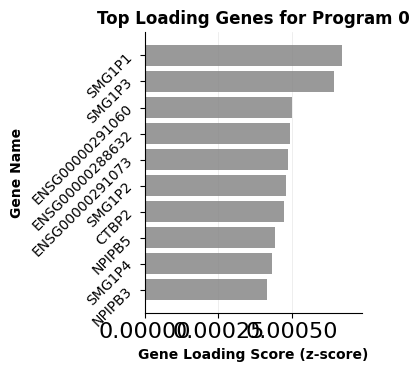

In [9]:

ax = plot_top_gene_per_program(mdata, Target_Program = 0, 
num_gene = 10, ax=None, save_path=None, save_name=None, 
figsize=(4, 4), show=True, file_to_dictionary=None)      

# GO enrichment

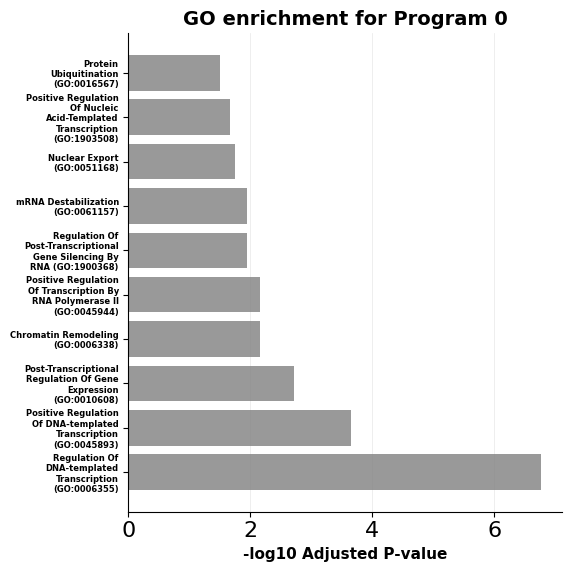

In [10]:
ax, wrapped_labels = top_GO_per_program(GO_path, Target_Program = 0, num_term = 10, p_value_name = "Adjusted P-value", 
 save_path = None, save_name = None,  ax=None, figsize=(6,6), show=True)

# Program correlation

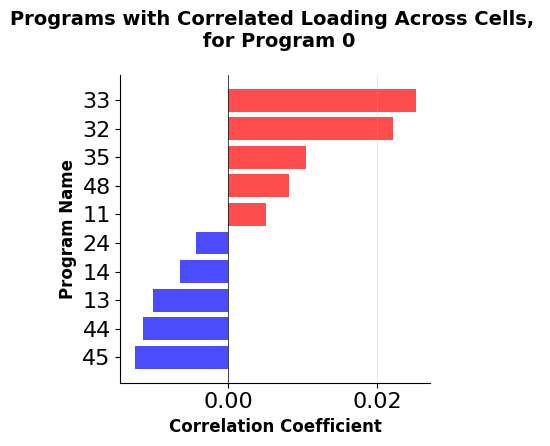

In [11]:
program_correlation = compute_program_correlation_matrix(mdata)

ax = analyze_program_correlations(program_correlation, Target_Program = 0, num_program = 5, 
save_path=None, save_name = None, figsize = (4, 4), show=True)

# Violin Plot

/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src/Interpretation/src/Program_QC_plots.py:357: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cell_type")


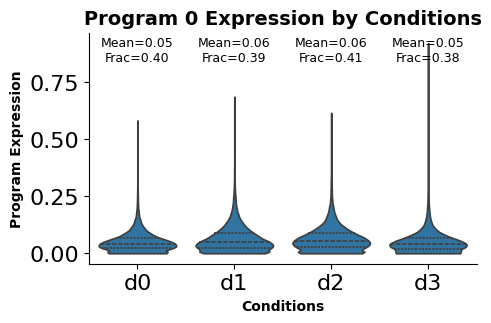

In [12]:
ax = plot_violin(mdata, Target_Program = 0, save_path=None, groupby = categorical_key,
                save_name=None, figsize=(5,3), show=True)

# Log2FC

In [ ]:

ax, df = plot_program_log2FC(perturb_path, Target = 0, tagert_col_name = "program_name",
 plot_col_name = "target_name", log2fc_col=log2fc_col, p_value = 0.05, figsize = (5,4), show = True, Day ="Day 0", gene_list = perturbed_gene_found)

# Plot heatmap

In [ ]:
ax = plot_program_heatmap(perturb_path_base, Target_Program = 0, tagert_col_name="program_name", plot_col_name="target_name", 
                log2fc_col=log2fc_col, p_value=0.05, save_path=None, save_name=None, sample=sample,
                figsize=(15, 5), show=True, ax=None)

# Volcano

In [ ]:
ax, p, texts  = plot_program_volcano(perturb_path, Target = 0, tagert_col_name="program_name", plot_col_name="target_name", 
                 log2fc_col=log2fc_col, down_thred_log=-0.05, up_thred_log=0.05, p_value=0.05, save_path=None, 
                 save_name=None, figsize=(5, 4), show=True, Day ="Day 0", gene_list = perturbed_gene_found)


# Expression Dotplot

In [33]:
ax = perturbed_program_dotplot(mdata, Target_Program=0, groupby=categorical_key, gene_list=df["target_name"].tolist(),
                     save_path=None, save_name=None, figsize=(5, 4), show=False, Day="Day 0") 
    

No significant Gene or Gene not Found


# Waterfall

In [ ]:
precomputed = f"{corr_matrix_path}/corr_program_matrix_{sample[0]}.txt" if corr_matrix_path else None
save = f"{corr_matrix_path}/corr_program_matrix_{sample[0]}.txt" if corr_matrix_path else None
waterfall_correlation = compute_program_waterfall_cor(perturb_path, precomputed_path=precomputed, save_path=save, log2fc_col=log2fc_col)

ax, texts = create_program_correlation_waterfall(waterfall_correlation, Target_Program = 0, top_num=5, save_path=None, 
                         save_name=None, figsize=(4, 4), show=True, Day ="Day 0") 

# Motif enrichment (didn't finish yet)

In [22]:
# plot top enriched enhancer or promoter
def plot_motif(motif_path, Target_Program = 0, num_term = 5, Type = "Enhancer", p_value_name = "Adjusted P-value",
save_path=None, save_name=None, figsize=(3, 5), show=False, ax=None, Day_idx = 0 ):

    # read txt file
    df = pd.read_csv(motif_path, sep='\t', index_col=0)

    # local to a program and isolate Term
    df_program = df.loc[df['program_name'] == Target_Program]

    # isolate day data 
    df_program = df_program.loc[df_program['sample'] == Day_idx]

    # rename index
    df_program.index = df_program['motif']

    # sort by the smallest p value
    df_sort = df_program[p_value_name].nsmallest(num_term)

    # -log10 tranform
    df_sort_log = -np.log10(df_sort)

    # Create figure/axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # Create horizontal bar plot
    bars = ax.barh(range(len(df_sort_log)), df_sort_log.values, color='#808080', alpha=0.8)

    # Customize the plot
    ax.set_yticks(range(len(df_sort_log)))
    ax.set_yticklabels(df_sort_log.index, fontsize=10)
    ax.set_xlabel('Adjusted P-value(-10)', fontsize=11)
    ax.set_title(f"{Type} Enrichment, Day {Day_idx} \n Program {program_num}", fontsize=14, fontweight='bold')


    # Format x-axis to match your reference
    ax.set_xlim(0, max(df_sort_log.values))
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

    # Add grid
    ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Adjust layout (only in standalone mode)
    if ax is None:
        plt.tight_layout()
    
    # Save if path provided (only in standalone mode)
    if save_path and ax is None:
        fig.savefig(f'{save_path}/{save_name}.svg', format='svg', bbox_inches='tight', dpi=300)
    

    # Control whether to display the plot (only in standalone mode)
    if ax is None:
        if show:
            plt.show()
        else:
            plt.close(fig)
    
    
    return ax 


In [23]:
motif_path = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Script/Revant_code/orginal_code/shared/250110_ipsc_ec_dashboard_setup/cNMF_100/cNMF_100_promoter_test_pearsonr_sample_D0_motif_enrichment.txt"


# Make PDF for programs

In [ ]:
waterfall_correlation = {}

for samp in sample:
    precomputed = f"{corr_matrix_path}/corr_program_matrix_{samp}.txt" if corr_matrix_path else None
    save = f"{corr_matrix_path}/corr_program_matrix_{samp}.txt" if corr_matrix_path else None
    df = compute_program_waterfall_cor(f"{perturb_path_base}_{samp}.txt", precomputed_path=precomputed, save_path=save, log2fc_col=log2fc_col)
    waterfall_correlation[samp] = (df)


program_correlation = compute_program_correlation_matrix(mdata)

In [ ]:

create_comprehensive_program_plot(
    mdata=mdata,
    perturb_path_base=perturb_path_base,
    GO_path=GO_path,
    waterfall_correlation=waterfall_correlation,
    program_correlation=program_correlation,
    file_to_dictionary=file_to_dictionary,
    Target_Program='1',
    top_program=5,
    top_enrichned_term = 10,
    groupby=categorical_key,
    tagert_col_name="program_name",
    plot_col_name="target_name",
    log2fc_col=log2fc_col,
    down_thred_log=-0.05,
    up_thred_log=0.05,
    p_value=0.05, 
    save_path=None,
    save_name="Test",
    figsize=(35, 40),
    square_plots=True,
    sample= sample,
    show=True,
    PDF=True,
    gene_list=perturbed_gene_found,
    subsample_frac=subsample_frac
)


In [ ]:
# Graph all pdf 
os.makedirs(save_path, exist_ok=True)                                                                                                           

programs_to_plot =  list(mdata[prog_key].var_names)
for program in programs_to_plot:

    create_comprehensive_program_plot(
        mdata=mdata,
        perturb_path_base=perturb_path_base,
        GO_path=GO_path,
        waterfall_correlation=waterfall_correlation,
        program_correlation=program_correlation,
        file_to_dictionary=file_to_dictionary,
        Target_Program=program,
        top_program=5,
        top_enrichned_term = 10,
        groupby=categorical_key,
        tagert_col_name="program_name",
        plot_col_name="target_name",
        log2fc_col=log2fc_col,
        down_thred_log=-0.05,
        up_thred_log=0.05,
        p_value=0.05, 
        save_path=save_path,
        save_name = program,
        figsize=(35, 35),
        sample=sample,
        square_plots=True,
        show=True,
        PDF=True,
        gene_list=perturbed_gene_found,
        subsample_frac=subsample_frac
    )


# Make PDFs for all programs

In [ ]:
merge_pdfs_in_folder(save_path, 'Program.PDF')
#merge_svgs_to_pdf(save_path)

Found 272 PDF files
